<a href="https://colab.research.google.com/github/tal21-linares/curso-ia-para-economia/blob/main/Dataton_AlejandroVelandia_SebastianCasas_TaliaLinares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import warnings

In [ ]:

pd.options.display.max_columns = None

pd.options.display.float_format = '{:,.2f}'.format

Reto 1: Integración de la Información

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving banco_transacciones.csv to banco_transacciones (1).csv
Saving banco_clientes.csv to banco_clientes (1).csv


In [ ]:
df_clientes = pd.read_csv('banco_clientes.csv')
df_transacciones = pd.read_csv('banco_transacciones.csv')

2.

In [ ]:
df_merged = pd.merge(df_clientes, df_transacciones,
                     on='ID_Cliente',
                     how='left')

3.

In [ ]:
print(df_merged.shape)

(1000, 7)


4.

In [ ]:
df_merged.head(3)

,ID_Cliente,Edad,Ingreso_Mensual,Genero,Saldo_Cuenta,Cant_Productos,Fuga_Ultimo_Mes
0,1,46.03,"2,812,419.04",femenino,"2,058.47",1.00,0.00
1,2,61.56,"832,327.82",otro,"2,581.61",1.00,1.00
2,3,48.47,"2,694,335.55",masculino,"6,285.61",4.00,0.00


Reto 2: Limpieza


1.

In [ ]:
df_merged['Genero'].unique()

array(['femenino', 'otro', 'masculino'], dtype=object)

In [ ]:
df_merged['Genero'] = df_merged['Genero'].str.strip().str.lower()


In [ ]:
df_merged['Genero'] = df_merged['Genero'].replace({
    'f': 'Femenino',
     'm': 'Masculino',
    'M': 'Masculino',
     'otro': 'Otro'

})

3.

In [ ]:
df_merged[df_merged['Edad'] > 100]

,ID_Cliente,Edad,Ingreso_Mensual,Genero,Saldo_Cuenta,Cant_Productos,Fuga_Ultimo_Mes


In [ ]:
df_merged.loc[df_merged['Edad'] > 100, 'Edad'] = df_merged['Edad'].median()

2.

In [ ]:

df_merged['Edad'] = df_merged['Edad'].fillna(df_merged['Edad'].median())

df_merged['Ingreso_Mensual'] = df_merged['Ingreso_Mensual'].fillna(df_merged['Ingreso_Mensual'].median())

df_merged['Saldo_Cuenta'] = df_merged['Saldo_Cuenta'].fillna(0)
df_merged['Cant_Productos'] = df_merged['Cant_Productos'].fillna(0)


df_merged['Fuga_Ultimo_Mes'] = df_merged['Fuga_Ultimo_Mes'].fillna(0)



In [ ]:
df_merged.isnull().sum()

,0
ID_Cliente,0
Edad,0
Ingreso_Mensual,0
Genero,0
Saldo_Cuenta,0
Cant_Productos,0
Fuga_Ultimo_Mes,0


Reto 3: Transformación

In [ ]:
df_merged['Ingreso_Anual'] = df_merged['Ingreso_Mensual'] * 12




In [ ]:

tabla_resumen = df_merged.groupby(['Genero', 'Fuga_Ultimo_Mes'])['Saldo_Cuenta'].mean().reset_index()

tabla_resumen = tabla_resumen.rename(columns={'Saldo_Cuenta': 'Saldo_Promedio'})


print(tabla_resumen)



      Genero  Fuga_Ultimo_Mes  Saldo_Promedio
0   femenino             0.00        7,522.95
1   femenino             1.00        1,893.42
2  masculino             0.00        6,512.50
3  masculino             1.00        1,191.77
4       otro             0.00        7,121.20
5       otro             1.00        1,457.27


Reto 4: Análisis Exploratorio - EDA


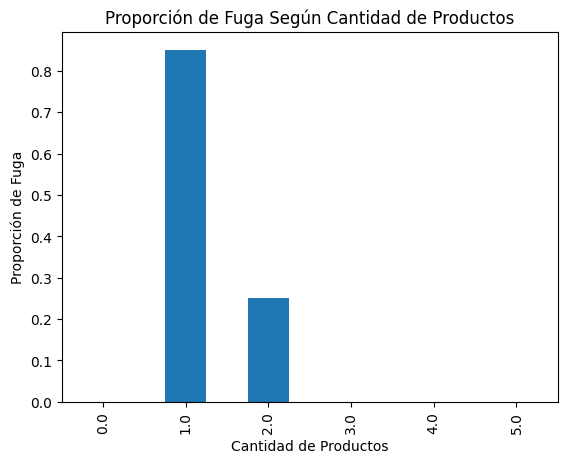

In [ ]:
import matplotlib.pyplot as plt

fuga_por_productos = df_merged.groupby('Cant_Productos')['Fuga_Ultimo_Mes'].mean()

plt.figure()
fuga_por_productos.plot(kind='bar')
plt.title('Proporción de Fuga Según Cantidad de Productos')
plt.xlabel('Cantidad de Productos')
plt.ylabel('Proporción de Fuga')

plt.show()

El análisis de la proporción de fuga según la cantidad de productos evidencia una relación inversa entre el nivel de vinculación del cliente y su probabilidad de abandono. En particular, los clientes que cuentan con un solo producto presentan una tasa de fuga significativamente alta, cercana al 80%, mientras que aquellos con dos productos muestran una reducción considerable en esta proporción, ubicándose alrededor del 20%–30%. Este resultado sugiere que a medida que aumenta la cantidad de productos financieros contratados, se incrementa el grado de compromiso del cliente con la entidad, elevando los costos de cambio y reduciendo su propensión a abandonar el banco. En este sentido, la baja diversificación en el uso de productos financieros se configura como un factor crítico de riesgo de fuga, lo que pone en evidencia la necesidad de fortalecer estrategias de vinculación y profundización financiera para mejorar la retención de clientes.

<Figure size 640x480 with 0 Axes>

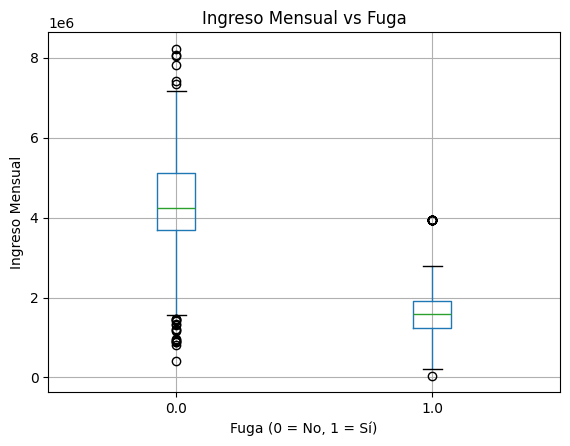

In [ ]:

plt.figure()
df_merged.boxplot(column='Ingreso_Mensual', by='Fuga_Ultimo_Mes')

plt.title('Ingreso Mensual vs Fuga')
plt.suptitle('')
plt.xlabel('Fuga (0 = No, 1 = Sí)')
plt.ylabel('Ingreso Mensual')

plt.show()

El análisis del ingreso mensual según la condición de fuga muestra que los clientes que permanecen en el banco presentan, en promedio, niveles de ingreso superiores y una mayor dispersión, incluyendo varios valores altos, mientras que los clientes que abandonan la entidad se concentran en rangos de ingreso más bajos.
Este patrón sugiere que la fuga no es aleatoria, sino que está asociada al perfil económico del cliente, aquellos con menores ingresos tienden a percibir menor valor en la relación con el banco o enfrentan mayores restricciones financieras, lo que incrementa su sensibilidad a costos y su propensión a cambiar de entidad. En contraste, los clientes de mayores ingresos parecen estar más vinculados y satisfechos con los servicios ofrecidos, lo que reduce su probabilidad de abandono.

Reto 5: Preparación para Machine Learning

In [ ]:

df_merged.columns = df_merged.columns.str.strip()


if 'Genero' in df_merged.columns:

    df_merged = pd.get_dummies(df_merged, columns=['Genero'], drop_first=True)

else:
    print("La columna 'Genero' no está disponible. Columnas actuales:")
    print(df_merged.columns)

La columna 'Genero' no está disponible. Columnas actuales:
Index(['ID_Cliente', 'Edad', 'Ingreso_Mensual', 'Saldo_Cuenta',
       'Cant_Productos', 'Fuga_Ultimo_Mes', 'Ingreso_Anual',
       'Genero_masculino', 'Genero_otro'],
      dtype='object')


In [ ]:
df_merged.head()

,ID_Cliente,Edad,Ingreso_Mensual,Saldo_Cuenta,Cant_Productos,Fuga_Ultimo_Mes,Genero_m,Genero_otro
0,1,46.033413,2.812419e+06,2058.469892,1.0,0.0,False,False
1,2,61.556330,8.323278e+05,2581.611324,1.0,1.0,False,True
2,3,48.472947,2.694336e+06,6285.609334,4.0,0.0,True,False
3,4,37.087825,5.412067e+06,16395.151188,4.0,0.0,False,False
4,5,NaN,4.598928e+06,15631.855902,3.0,0.0,True,False


*2.*

In [ ]:
from sklearn.preprocessing import StandardScaler


df_merged.columns = df_merged.columns.str.strip()


scaler = StandardScaler()


cols_to_scale = ['Ingreso_Mensual', 'Saldo_Cuenta']

cols_existentes = [col for col in cols_to_scale if col in df_merged.columns]


df_merged[cols_existentes] = scaler.fit_transform(df_merged[cols_existentes])


print(df_merged[cols_existentes].head())

   Ingreso_Mensual  Saldo_Cuenta
0            -0.60         -0.54
1            -1.87         -0.47
2            -0.67          0.06
3             1.08          1.51
4             0.55          1.40
